# 06. DECam Streak Photometry
Written by Kiyoaki Okudaira and Meredith Rawls<br>
*University of Washington / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
A notebook to photometry satellite streak and query the SatChecker Field Of View (FOV) service.<br>
<br>
**History**<br>
coding 2026-02-21 : 1st coding

### Import and initial settings
**Standard libraries**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from os import path
import pickle
import json

from scipy.stats import sigmaclip
import requests

from IPython.display import clear_output

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from photutils.aperture import RectangularAperture, aperture_photometry

from tqdm.notebook import tqdm

**Satphotometry library**

In [3]:
import satphotometry as sp

**Import file settings**

In [4]:
# project directory
PATH_project = '/astro/store/shire/kiyoaki/ASTR499/'

PATH_input   = PATH_project + 'input/'
PATH_output  = PATH_project + 'output/'

PATH_image   = PATH_input  + 'fits_data/'
PATH_session = PATH_output + 'session/'

# ORIGINAL streak list from Alex
fname_streak_list = 'streaks_augmented_20230817.csv'
PATH_streak_list  = fname_streak_list + 'decam_streak_list/' + fname_streak_list

In [ ]:
# image_path = "/astro/store/shire/kiyoaki/ASTR499/input/fits_data/" # Directory where DECam images are saved | str
# output_path = "/astro/store/shire/kiyoaki/ASTR499/output/"
# group_num = 1
# row_num   = 1

**Process method setting**

In [ ]:
paralell_process = True
if paralell_process:
    from concurrent.futures import ThreadPoolExecutor, as_completed

### Load Streak Dataset
Dataset is grouped by EXPNUM because if the EXPNUM is the same, the request to satchecker is the same．

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_05_identify.pkl', 'rb') as f:
    streak_table = pickle.load(f)
streak_table = streak_table.group_by("expnum")
output = []

mag_arcsec_list = [None] * len(streak_table)

### Photometry
**Photometry (single processing)**

In [ ]:
if paralell_process is False:
    for row in tqdm(streak_table):
        basename = path.basename(row["archive_filename"])
        md5sum = row["md5sum"]
        expnum = row["expnum"]
        ccdnum = row["ccdnum"]
        streak_ID = row["streakID"]
        idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        hdu = fits.open(save_path)
        main_header = hdu[0].header
        ccd_header = hdu[1].header
        ccd_data = hdu[1].data
        ccd_wcs = WCS(ccd_header)

        ccd_data = fits.getdata(save_path,1)
        rotated_img,r_matrix,r_pararell = sp.imgrotation.rotate_image(ccd_data, row["rt_angle"], row["initial_streak_coord"], True, 100, True)

        streak_x_min = row["streak_x_min"]
        streak_x_max = row["streak_x_max"]
        streak_y     = row["streak_y"]
        sigma_mean   = row["streak_sigma"]

        # rotation
        def _inv_rot(x, y, r_matrix, r_pararell, wcs):
            p = np.array([x, y], dtype=float)
            src_xy = r_matrix @ (p - r_pararell)
            src_radec = wcs.pixel_to_world(src_xy[0], src_xy[1])
            return src_xy,src_radec

        streak_sc_src_xy,streak_sc_radec = _inv_rot(streak_x_min, streak_y, r_matrix, r_pararell, ccd_wcs)
        streak_ec_src_xy,streak_ec_radec = _inv_rot(streak_x_max, streak_y, r_matrix, r_pararell, ccd_wcs)

        streak_s1_src_xy,streak_s1_radec = _inv_rot(streak_x_min, streak_y-3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
        streak_s2_src_xy,streak_s2_radec = _inv_rot(streak_x_min, streak_y+3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
        streak_e1_src_xy,streak_e1_radec = _inv_rot(streak_x_max, streak_y-3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
        streak_e2_src_xy,streak_e2_radec = _inv_rot(streak_x_max, streak_y+3*sigma_mean, r_matrix, r_pararell, ccd_wcs)

        # image plot
        # quad for plot
        quad_x_src = [
            len(ccd_data[0]) - streak_s1_src_xy[0],
            len(ccd_data[0]) - streak_s2_src_xy[0],
            len(ccd_data[0]) - streak_e2_src_xy[0],
            len(ccd_data[0]) - streak_e1_src_xy[0],
            len(ccd_data[0]) - streak_s1_src_xy[0]
        ]

        quad_y_src = [
            streak_s1_src_xy[1],
            streak_s2_src_xy[1],
            streak_e2_src_xy[1],
            streak_e1_src_xy[1],
            streak_s1_src_xy[1]
        ]

        quad_x_rt = [
            0,
            0,
            streak_x_max - streak_x_min,
            streak_x_max - streak_x_min,
            0
        ]

        quad_y_rt = [
            streak_y-3*sigma_mean,
            streak_y+3*sigma_mean,
            streak_y+3*sigma_mean,
            streak_y-3*sigma_mean,
            streak_y-3*sigma_mean
        ]

        # photometry
        width = streak_x_max-streak_x_min
        height = 6*sigma_mean

        # On-streak
        ap_in = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y), w=width, h=height, theta=0)

        # Off streak
        ap_out_1 = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y+height), w=width, h=height/2, theta=0)
        ap_out_2 = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y-height), w=width, h=height/2, theta=0)

        # Count and Area
        phot_in  = aperture_photometry(rotated_img, ap_in)
        phot_out_1 = aperture_photometry(rotated_img, ap_out_1)
        phot_out_2 = aperture_photometry(rotated_img, ap_out_2)

        sum_in  = phot_in["aperture_sum"][0]
        sum_out = phot_out_1["aperture_sum"][0] + phot_out_2["aperture_sum"][0]

        area_in  = ap_in.area
        area_out = ap_out_1.area + ap_out_2.area

        # Background
        bkg_mean  = sum_out/area_out

        # Flux
        arc_per_pix = 0.27
        flux_net = sum_in - bkg_mean * area_in
        flux_pix = flux_net/(width*height)
        flux_arcsec = flux_pix / (arc_per_pix**2)
        s_n = flux_pix/bkg_mean

        # Magnitude
        mag_arcsec = -2.5*np.log10(flux_arcsec) + 22.5

        mag_arcsec_list[idx] = mag_arcsec
        
        clear_output(wait=True)

**Photometry (paralell processing)**

In [ ]:
if paralell_process:
    def process_row(args):
        idx, row, image_path = args

        basename = path.basename(row["archive_filename"])
        ccdnum = row["ccdnum"]

        save_path = (
            image_path
            + path.splitext(path.splitext(basename)[0])[0]
            + "_CCD_{0}".format(ccdnum)
            + path.splitext(path.splitext(basename)[0])[1]
            + path.splitext(basename)[1]
        )

        # FITS読み込み
        with fits.open(save_path) as hdu:
            main_header = hdu[0].header
            ccd_header = hdu[1].header
            ccd_data = hdu[1].data
            ccd_wcs = WCS(ccd_header)

        # 元コード準拠
        ccd_data = fits.getdata(save_path, 1)

        rotated_img, r_matrix, r_pararell = sp.imgrotation.rotate_image(
            ccd_data,
            row["rt_angle"],
            row["initial_streak_coord"],
            True,
            100,
            True
        )

        streak_x_min = row["streak_x_min"]
        streak_x_max = row["streak_x_max"]
        streak_y     = row["streak_y"]
        sigma_mean   = row["streak_sigma"]

        # photometry
        width = streak_x_max - streak_x_min
        height = 6 * sigma_mean

        # On-streak
        ap_in = RectangularAperture(
            ((streak_x_min + streak_x_max) / 2, streak_y),
            w=width,
            h=height,
            theta=0
        )

        # Off-streak
        ap_out_1 = RectangularAperture(
            ((streak_x_min + streak_x_max) / 2, streak_y + height),
            w=width,
            h=height / 2,
            theta=0
        )
        ap_out_2 = RectangularAperture(
            ((streak_x_min + streak_x_max) / 2, streak_y - height),
            w=width,
            h=height / 2,
            theta=0
        )

        # Count and Area
        phot_in = aperture_photometry(rotated_img, ap_in)
        phot_out_1 = aperture_photometry(rotated_img, ap_out_1)
        phot_out_2 = aperture_photometry(rotated_img, ap_out_2)

        sum_in = phot_in["aperture_sum"][0]
        sum_out = phot_out_1["aperture_sum"][0] + phot_out_2["aperture_sum"][0]

        area_in = ap_in.area
        area_out = ap_out_1.area + ap_out_2.area

        # Background
        bkg_mean = sum_out / area_out

        # Flux
        arc_per_pix = 0.27
        flux_net = sum_in - bkg_mean * area_in
        flux_pix = flux_net / (width * height)
        flux_arcsec = flux_pix / (arc_per_pix ** 2)

        # Magnitude
        if flux_arcsec > 0:
            mag_arcsec = -2.5 * np.log10(flux_arcsec) + 22.5
        else:
            mag_arcsec = np.nan

        return idx, mag_arcsec


    # ===== 並列実行 =====
    mag_arcsec_list = np.full(len(streak_table), np.nan)

    max_workers = 12  # 適宜調整。4, 8, 12 などで試すとよい
    tasks = [(idx, row, PATH_image) for idx, row in enumerate(streak_table)]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_row, task) for task in tasks]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing"):
            idx, mag_arcsec = future.result()
            mag_arcsec_list[idx] = mag_arcsec

    streak_table["mag_arcsec"] = mag_arcsec_list
    with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'wb') as f:
        pickle.dump(streak_table, f)

Processing:   0%|          | 0/12262 [00:00<?, ?it/s]

**Save session**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'rb') as f:
    streak_table = pickle.load(f)
# streak_table = streak_table.group_by("expnum")

**Save result as CSV**

In [ ]:
streak_table.remove_columns(["initial_gauss_y", "initial_amplitude", "initial_ground", "initial_mu", "initial_sigma", "gauss_y", "amplitude", "ground", "mu", "sigma","initial_streak_coord"])
streak_table.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.csv', overwrite=True)

### Magnitude conversion
Convert surface brightness into magnitude

In [ ]:
arc_per_pix = 0.27

mag_raw_list        = [None] * len(streak_table)
fwhm_list           = [None] * len(streak_table)
omega_arcsec_s_list = [None] * len(streak_table)
mag_corr_list       = [None] * len(streak_table)
mag_stat_list       = [None] * len(streak_table)
mag_zen_list        = [None] * len(streak_table)

for row in tqdm(streak_table):
    if row["mag_arcsec"] == None or row["magzero"] == None:
        continue
    basename = path.basename(row["archive_filename"])
    md5sum = row["md5sum"]
    expnum = row["expnum"]
    ccdnum = row["ccdnum"]
    streak_ID = row["streakID"]
    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

    save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

    hdu = fits.open(save_path)
    main_header = hdu[0].header
    exptime = main_header["EXPTIME"]
    mag_raw = row["mag_arcsec"] + (row["magzero"] - 22.5)

    mag_corr = mag_raw - 2.5 * np.log10(exptime)
    fwhm = (2.355 * row["streak_sigma"]) * arc_per_pix

    data = json.load(open(PATH_output + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))

    if row["norad_id"] == None:
        omega_deg_s = 0.8
    else:
        positions = data["data"]["satellites"][f"{row["name"]} ({row["norad_id"]})"]["positions"]

        ra1  = positions[0]["ra"]
        dec1 = positions[0]["dec"]
        jd1  = positions[0]["julian_date"]
        ra2  = positions[-1]["ra"]
        dec2 = positions[-1]["dec"]
        jd2  = positions[-1]["julian_date"]

        c1 = SkyCoord(ra=ra1*u.deg, dec=dec1*u.deg, frame="icrs")
        c2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg, frame="icrs")

        delta_theta_deg = c1.separation(c2).deg

        delta_t_sec = (jd2 - jd1) * 86400.0

        omega_deg_s = delta_theta_deg / delta_t_sec

    omega_arcsec_s = omega_deg_s * 3600.0

    mag_stat = mag_corr - 2.5 * np.log10(omega_arcsec_s * fwhm)
    mag_zen  = mag_stat - 5 * np.log10(row["airmass"])

    mag_raw_list[idx] = mag_raw
    fwhm_list[idx] = fwhm
    omega_arcsec_s_list[idx] = omega_arcsec_s
    mag_corr_list[idx] = mag_corr
    mag_stat_list[idx] = mag_stat
    mag_zen_list[idx] = mag_zen

streak_table["mag_raw"] = mag_raw_list
streak_table["fwhm"] = fwhm_list
streak_table["omega_arcsec_s"] = omega_arcsec_s
streak_table["mag_corr"] = mag_corr_list
streak_table["mag_stat"] = mag_stat_list
streak_table["mag_zen"] = mag_zen_list

  0%|          | 0/12262 [00:00<?, ?it/s]

### Starlink generation
Add starlink generation to streak list<br>

**Canvas**

In [ ]:
streak_table = streak_table.group_by("name")
starlink_generation = [None] * len(streak_table)

**SatChecker query**

In [ ]:
for group in tqdm(streak_table.groups):
    if "STARLINK" in str(group[0]["name"]).upper():
        url = 'https://satchecker.cps.iau.org/tools/get-satellite-data/'
        params = {'id': group[0]["norad_id"],
                'id_type': 'catalog'
                }

        r = requests.get(url, params=params)

        if r.status_code == 200:
            generation = r.json()["data"][0]["generation"]

            for row in group:
                streak_ID = row["streakID"]
                try:
                    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]
                    starlink_generation[idx] = generation
                except:
                    pass

for i in range(len(streak_table)):
    if streak_table[i]["generation"] == None:
        streak_table[i]["generation"] = "others"

  0%|          | 0/1316 [00:00<?, ?it/s]

**Save result**

In [ ]:
streak_table["generation"] = starlink_generation
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'wb') as f:
    pickle.dump(streak_table, f)

**Restore session back-up**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'rb') as f:
    streak_table = pickle.load(f)

In [ ]:
# altitude_list = []
# azimuth_list  = []

# for row in streak_table:
#     basename = path.basename(row["archive_filename"])
#     data = json.load(open(PATH_output + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))
#     positions = data["data"]["satellites"][f"{row["name"]} ({row["norad_id"]})"]["positions"]
#     altitudes = [d["altitude"] for d in positions]
#     azimuths  = [d["azimuth"] for d in positions]

#     mean_altitude = np.mean(altitudes)
#     mean_azimuth  = np.mean(azimuths)

#     altitude_list.append(mean_altitude)
#     azimuth_list.append(mean_azimuth)

# streak_table["al"] = altitude_list
# streak_table["az"] = azimuth_list

### Result (general)
**Number of streaks**

In [ ]:
streak_table_masked = streak_table[(streak_table["mag_arcsec"] != None) & (streak_table["magzero"] != None)]
print(f'Photometry succeeded : {len(streak_table_masked)} streaks')

**Magnitude histogram**

/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:396: RuntimeWarning: invalid value encountered in greater_equal
  keep = (a >= first_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:397: RuntimeWarning: invalid value encountered in less_equal
  keep &= (a <= last_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:837: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:838: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


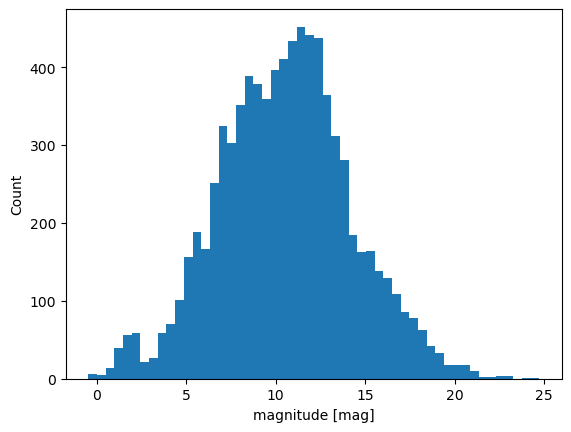

In [10]:
_ = plt.hist(streak_table_masked['mag_zen'], bins="auto")
plt.xlabel("magnitude [mag]")
plt.ylabel("Count")
plt.show()

In [ ]:
print(f'Number of streaks brighter than MAG 7 : {(streak_table_masked['mag_zen'] < 7).sum()}')

/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/astropy/table/column.py:342: RuntimeWarning: invalid value encountered in less
  result = getattr(super(Column, self), op)(other)


np.int64(1370)

**Skyplot**

In [ ]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)
gen = np.asarray(streak_table_masked["generation"])

r = 90 - alt

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, polar=True)

generations = np.unique(gen)
markers = ["o", "s", "^"]   # 見やすい形に変更

sc_list = []

for i, g in enumerate(generations):
    mask = (gen == g)
    print(g, np.sum(mask))  # 確認用

    sc = ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap="plasma_r",
        s=6,   # 大きくする
        marker=markers[i % len(markers)],
        label=f"Generation {g}"
    )
    sc_list.append(sc)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_ylim(0, 90)
ax.set_rgrids([0, 30, 60, 90], labels=["90°", "60°", "30°", "0°"])

cbar = plt.colorbar(sc_list[0], ax=ax, pad=0.1)
cbar.set_label("Brightness [mag]")

# ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.05))
ax.set_title("Sky Plot (Colored by brightness, All streaks)")

plt.show()

**Histogram (observation time)**

In [ ]:
obs_times = Time(streak_table["dateobs_center"])

from datetime import timezone, timedelta

# UTC-4
# utc_minus4 = timezone(timedelta(hours=-(70.806389/15)))
utc_minus4 = timezone(timedelta(hours=-4))

# astropy Time → UTC-4 datetime
dt_utc = obs_times.to_datetime()
dt_local = np.array([
    t.replace(tzinfo=timezone.utc).astimezone(utc_minus4)
    for t in dt_utc
])

hours = np.array([
    t.hour + t.minute / 60 + t.second / 3600 + t.microsecond / 3600 / 1e6
    for t in dt_local
])

bins = np.arange(0, 16.0 + 0.5, 0.5)

hours_shifted = (hours - 16) % 24

mask = (hours_shifted >= 0) & (hours_shifted <= 16)
hours_plot = hours_shifted[mask]

# Plot
plt.figure(figsize=(10, 5))
plt.hist(hours_plot, bins=bins)

plt.xlabel("Time of day [UTC-4]")
plt.ylabel("Count")
plt.title("Histogram of observation times (UTC-4)")

# Label
xticks = np.arange(0, 17, 2)
xtick_labels = [f"{int((x+16)%24):02d}:00" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlim(0, 16)

plt.grid(alpha=0.3)
plt.show()

### Result (Starlink)

In [ ]:
bin_width = 0.2
bins = np.arange(2, 12 + bin_width, bin_width)

plt.xlim([2,11])

for group in streak_table_masked.groups:
    plt.hist(group['mag_zen'], bins=bins, alpha=0.5, label="Starlink "+group[0]["generation"])

plt.xlabel("magnitude [mag]")
plt.ylabel("Count")
plt.legend()
plt.title("brightness of Starlink satellites captured by DECam")
plt.show()

In [ ]:
# streak_table_masked = streak_table_masked.group_by("norad_id")
for group in streak_table_masked.groups:
    plt.scatter(group["name"], group["mag_zen"], s=8, alpha=0.75, label="Starlink "+group[0]["generation"])
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y')
plt.ylabel("magnitude [mag]")
plt.title("brightness of Starlink satellites captured by DECam")
plt.show()